In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from lightgbm import LGBMClassifier, LGBMRegressor
import lightgbm as lgb
from xgboost import XGBClassifier, XGBRegressor
import joblib
from data_processing import load_and_prepare_dataset
from itertools import product

In [34]:
df = load_and_prepare_dataset(
    'dataset.csv',
    drop_cols=[
        'fast_break_pct_avg_diff',
        'fast_break_pct_rolling_5_diff',
        'points_off_turnover_pct_avg_diff',
        'points_off_turnover_pct_rolling_5_diff'
    ]
)

# %%

df.loc[df['team_home_away'] == 1, 'margin_estimate'] = df['margin_estimate'] + 7.00
df.loc[df['team_home_away'] == 0, 'margin_estimate'] = df['margin_estimate'] - 7.00
df.loc[df['team_home_away'] == 1, 'point_differential_avg_diff'] = df['margin_estimate'] + 6.90
df.loc[df['team_home_away'] == 0, 'point_differential_avg_diff'] = df['margin_estimate'] - 6.90


In [35]:
base_train_end = '2020-10-31'
meta_train_end = '2022-10-31'
validation_end = '2024-10-31'

def games_played_weight(games_played, k=10):
    games_played = pd.to_numeric(games_played, errors='coerce').fillna(0)
    return np.minimum(1.0, games_played / float(k))


df['target'] = df['spread']
df.drop(columns=['spread'], inplace=True)

base_train_df = df[df['game_date'] <= base_train_end].copy()
meta_train_df = df[(df['game_date'] > base_train_end) & (df['game_date'] <= meta_train_end)].copy()
validation_df = df[(df['game_date'] > meta_train_end) & (df['game_date'] <= validation_end)].copy()
test_df = df[df['game_date'] > validation_end].copy()

test_game_dates = pd.to_datetime(test_df['game_date']).copy()

base_train_sample_weights = games_played_weight(base_train_df['games_played'])
meta_train_sample_weights = games_played_weight(meta_train_df['games_played'])
validation_sample_weights = games_played_weight(validation_df['games_played'])

base_train_df.drop(columns=['game_date', 'game_id'], inplace=True)
meta_train_df.drop(columns=['game_date', 'game_id'], inplace=True)
validation_df.drop(columns=['game_date', 'game_id'], inplace=True)
test_df.drop(columns=['game_date', 'game_id'], inplace=True)

print(f"Base train rows: {len(base_train_df)}")
print(f"Meta train rows: {len(meta_train_df)}")
print(f"Validation rows: {len(validation_df)}")
print(f"Test rows: {len(test_df)}")


Base train rows: 161386
Meta train rows: 18076
Validation rows: 22230
Test rows: 22026


In [36]:
stat_cols = [
    'threes_advantage','threes_disadvantage','two_pointers_advantage','two_pointers_disadvantage',
    'free_throws_advantage','free_throws_disadvantage','off_vs_def','def_vs_off','tov_vs_stl','stl_vs_tov',
    'orb_vs_drb','drb_vs_orb','pace_diff','exp_poss','efg_vs_efg_allowed','efg_allowed_vs_efg','margin_estimate',
    'three_variance_diff','score_variance_diff','def_score_variance_diff','off_eff_variance_diff','pace_variance_diff',
    'last_10_efficiency_diff','team_score_avg_diff','team_score_ewm_diff','opponent_team_score_avg_diff',
    'opponent_team_score_ewm_diff','poss_avg_diff','poss_ewm_diff','poss_opponent_avg_diff','poss_opponent_ewm_diff',
    'efg_avg_diff','efg_ewm_diff','efg_allowed_avg_diff','efg_allowed_ewm_diff','tov_avg_diff','tov_ewm_diff',
    'stl_rate_avg_diff','stl_rate_ewm_diff','orb_avg_diff','orb_ewm_diff','drb_avg_diff','drb_ewm_diff','ftr_avg_diff',
    'ftr_ewm_diff','foul_rate_avg_diff','foul_rate_ewm_diff','ppp_avg_diff','ppp_ewm_diff','two_pct_avg_diff',
    'two_pct_ewm_diff','two_pct_opponent_avg_diff','two_pct_opponent_ewm_diff','assist_rate_avg_diff',
    'assist_rate_ewm_diff','assist_to_fg_avg_diff','assist_to_fg_ewm_diff','block_rate_avg_diff','block_rate_ewm_diff',
    'three_pct_avg_diff','three_pct_ewm_diff','three_pct_opponent_avg_diff','three_pct_opponent_ewm_diff',
    'three_attempt_rate_avg_diff','three_attempt_rate_ewm_diff','allowed_three_attempt_rate_avg_diff',
    'allowed_three_attempt_rate_ewm_diff'
]

power_cols = ['sos','sos_opp','quad_score','net_eff_avg_diff','net_eff_ewm_diff','point_differential_avg_diff','point_differential_ewm_diff',
            'conference_strength_diff','win_loss_pct_diff','non_conf_win_loss_pct_diff','conference_nonconf_win_pct_diff',
            'luck_diff','rank_diff','power_rating_diff','off_eff_avg_diff','off_eff_ewm_diff','def_eff_avg_diff','def_eff_ewm_diff']

elo_cols = ['elo_diff']

context_cols = ['season','season_type','team_home_away','games_played']

target_cols = ['target','team_winner']

In [37]:
X_base_train = base_train_df.drop(columns=target_cols)
X_base_train_stat = X_base_train[stat_cols + context_cols]
X_base_train_power = X_base_train[power_cols + context_cols]
X_base_train_elo = X_base_train[elo_cols + context_cols]
y_base_train = base_train_df['target'].astype(int)

X_meta_train = meta_train_df.drop(columns=target_cols)
X_meta_train_stat = X_meta_train[stat_cols + context_cols]
X_meta_train_power = X_meta_train[power_cols + context_cols]
X_meta_train_elo = X_meta_train[elo_cols + context_cols]
y_meta_train = meta_train_df['target'].astype(int)

X_validation = validation_df.drop(columns=target_cols)
X_validation_stat = X_validation[stat_cols + context_cols]
X_validation_power = X_validation[power_cols + context_cols]
X_validation_elo = X_validation[elo_cols + context_cols]
y_validation = validation_df['target'].astype(int)

X_test = test_df.drop(columns=target_cols)
X_test_stat = X_test[stat_cols + context_cols]
X_test_power = X_test[power_cols + context_cols]
X_test_elo = X_test[elo_cols + context_cols]
y_test = test_df['target'].astype(int)


In [38]:
# Improved model parameters for better generalization and handling nonlinearity
params = dict(
    objective="regression",
    metric="mae",
    boosting_type="gbdt",
    learning_rate=0.04,           # Slower learning rate for more robust learning
    n_estimators=2000,             # More trees to compensate for lower learning rate
    max_depth=7,                   # Slightly deeper trees to fit more complex patterns
    num_leaves=96,                # More leaves to capture nonlinearity
    min_child_samples=50,          # Reduce overfitting, but not too high to retain learning small data regions
    feature_fraction=0.85,         # Try more features per tree
    bagging_fraction=0.85,         # Slightly more bagging for generalization
    bagging_freq=1,
    lambda_l1=1.0,                 # Slightly stronger L1 to encourage sparsity
    lambda_l2=6.0,                 # Slightly stronger L2 for regularization
    min_gain_to_split=0.005,       # Require a bit more information gain to split
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    early_stopping_rounds=200
    # Remove early_stopping_rounds, eval_set, eval_names, eval_metric, callbacks from constructor
)

model_stat = LGBMRegressor(**params)

print("\nTraining statistical prediction model (base-train split)...")
model_stat.fit(
    X_base_train_stat,
    y_base_train,
    #sample_weight=base_train_sample_weights,
    eval_set=[(X_base_train_stat, y_base_train), (X_meta_train_stat, y_meta_train)],
    eval_sample_weight=[base_train_sample_weights, meta_train_sample_weights],
    eval_names=['Base Train', 'Meta Train'],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=200, first_metric_only=True)]
)



Training statistical prediction model (base-train split)...
Training until validation scores don't improve for 200 rounds


,boosting_type,'gbdt'
,num_leaves,96
,max_depth,7
,learning_rate,0.04
,n_estimators,2000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [39]:
def evaluate_regression_thresholds(y_pred_raw, y_test, model_name):
    """
    Evaluate thresholds for the regression task, mapping predicted spread > threshold to win (1), else loss (0).
    Additionally, always compute the hard classification: pred > 0 => winner.
    Prints ROC AUC using the raw spread as a score for the winner class (y_test should be binary).
    """
    from sklearn.metrics import matthews_corrcoef, roc_auc_score

    thresholds = np.linspace(-10, 10, 21)  # Try thresholds from -10 to 10
    metrics = []

    # Compute ROC AUC for regression output as probabilities (using spread as score for winner class = 1)
    try:
        roc_auc = roc_auc_score(y_test, y_pred_raw)
        print(f"ROC AUC (raw regression scores): {roc_auc:.4f}")
    except Exception as e:
        print(f"ROC AUC computation failed: {str(e)}")

    for thresh in thresholds:
        # Mask spread prediction: classify as win (1) if pred > thresh, else loss (0)
        y_pred_thresh = (y_pred_raw > thresh).astype(int)

        # Calculate metrics for this threshold
        precision = precision_score(y_test, y_pred_thresh)
        recall = recall_score(y_test, y_pred_thresh)
        f1 = f1_score(y_test, y_pred_thresh)
        accuracy = accuracy_score(y_test, y_pred_thresh)
        mcc = matthews_corrcoef(y_test, y_pred_thresh)

        metrics.append([thresh, precision, recall, f1, accuracy, mcc])

    # Also evaluate the standard "pred > 0" as a classification prediction
    y_pred_binary = (y_pred_raw > 0).astype(int)
    binary_metrics = {
        "Precision": precision_score(y_test, y_pred_binary),
        "Recall": recall_score(y_test, y_pred_binary),
        "F1 Score": f1_score(y_test, y_pred_binary),
        "Accuracy": accuracy_score(y_test, y_pred_binary),
        "Matthews_CC": matthews_corrcoef(y_test, y_pred_binary)
    }
    print("\nMetrics for hard mask (prediction > 0 ==> Winner):")
    print(f"Precision: {binary_metrics['Precision']:.4f}")
    print(f"Recall:    {binary_metrics['Recall']:.4f}")
    print(f"F1 Score:  {binary_metrics['F1 Score']:.4f}")
    print(f"Accuracy:  {binary_metrics['Accuracy']:.4f}")
    print(f"MCC:       {binary_metrics['Matthews_CC']:.4f}\n")

    # Convert to DataFrame
    metrics_df = pd.DataFrame(
        metrics,
        columns=[
            "Threshold", "Precision", "Recall", "F1 Score", "Accuracy", "Matthews_CC",
        ]
    )

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=metrics_df, x="Threshold", y="Precision", label="Precision", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Recall", label="Recall", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="F1 Score", label="F1 Score", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Accuracy", label="Accuracy", marker="o")
    sns.lineplot(
        data=metrics_df,
        x="Threshold",
        y="Matthews_CC",
        label="Matthews Corr. Coefficient",
        marker="o",
        linestyle="--",
        color="darkgreen"
    )

    plt.xlabel("Spread Threshold (win if pred > thresh)")
    plt.ylabel("Score")
    plt.title(f"Threshold Optimization for Regression-as-Classification - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Best metrics over thresholds (MCC):")
    print(metrics_df.loc[metrics_df['Matthews_CC'].idxmax()])

    # Find and return the best threshold based on Matthews Correlation Coefficient (MCC)
    best_threshold = metrics_df.loc[metrics_df["Matthews_CC"].idxmax(), "Threshold"]

    return best_threshold

In [40]:
lgbm_stat_meta_train_pred = model_stat.predict(X_meta_train_stat)
lgbm_stat_validation_pred = model_stat.predict(X_validation_stat)
lgbm_stat_pred = model_stat.predict(X_test_stat)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def print_regression_stats(y_true, y_pred, model_name="Regression Model"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n===== {model_name} Regression Stats =====")
    print(f"Mean Squared Error (MSE):      {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE):{rmse:.4f}")
    print(f"Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"R^2 Score:                     {r2:.4f}")
    print("="*42)

# Example usage:
print_regression_stats(y_test, lgbm_stat_pred, "Statistical Model")


===== Statistical Model Regression Stats =====
Mean Squared Error (MSE):      151.0993
Root Mean Squared Error (RMSE):151.0993
Mean Absolute Error (MAE):     9.6013
R^2 Score:                     0.4004


In [41]:
def plot_feature_importance(model, X_train, model_name):
    feature_importances = model.feature_importances_
    feature_names = X_train.columns

    feat_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    top_20_features = feat_importance_df.sort_values(by="Importance", ascending=False).head(30)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.title(f"Top 20 Features - {model_name}")
    plt.show()

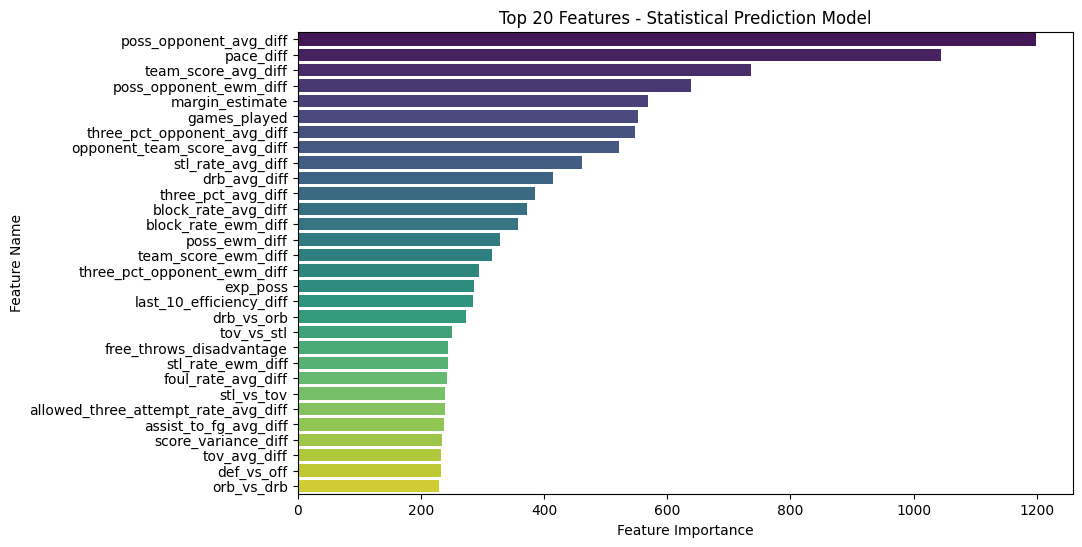

In [42]:
plot_feature_importance(model_stat, X_base_train_stat, "Statistical Prediction Model")


In [43]:
model_elo = LGBMRegressor(**params)

print("\nTraining elo prediction model (base-train split)...")
model_elo.fit(
    X_base_train_elo,
    y_base_train,
    #sample_weight=base_train_sample_weights,
    eval_set=[(X_base_train_elo, y_base_train), (X_meta_train_elo, y_meta_train)],
    eval_sample_weight=[base_train_sample_weights, meta_train_sample_weights],
    eval_names=['Base Train', 'Meta Train'],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=200, first_metric_only=True)]
)



Training elo prediction model (base-train split)...
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[5]	Base Train's auc: 0.798736	Base Train's l1: 11.1269	Meta Train's auc: 0.767778	Meta Train's l1: 10.4988
Evaluated only: auc


,boosting_type,'gbdt'
,num_leaves,96
,max_depth,7
,learning_rate,0.04
,n_estimators,2000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [44]:
lgbm_elo_meta_train_pred = model_elo.predict(X_meta_train_elo)
lgbm_elo_validation_pred = model_elo.predict(X_validation_elo)
lgbm_elo_pred = model_elo.predict(X_test_elo)

# Example usage:
print_regression_stats(y_test, lgbm_elo_pred, "Elo Model")


===== Elo Model Regression Stats =====
Mean Squared Error (MSE):      222.2488
Root Mean Squared Error (RMSE):222.2488
Mean Absolute Error (MAE):     11.5905
R^2 Score:                     0.1181


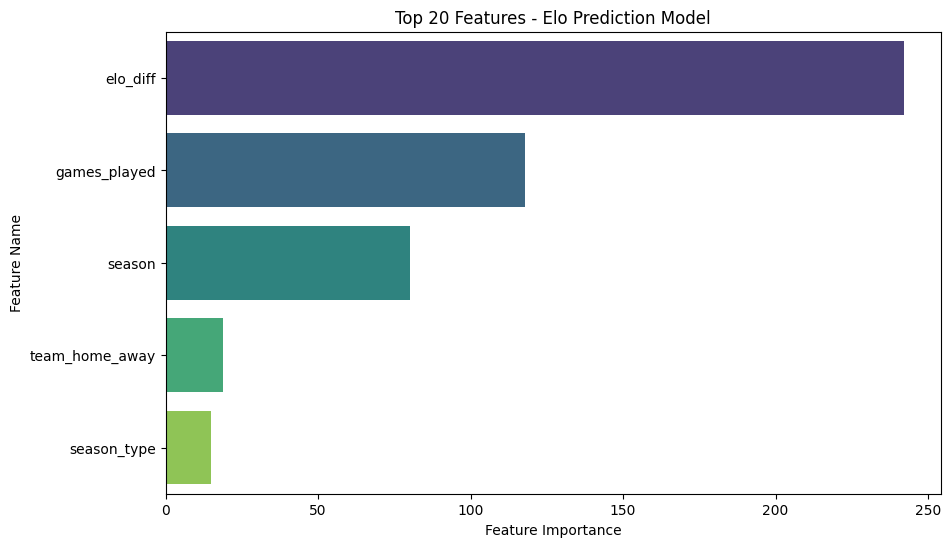

In [45]:
plot_feature_importance(model_elo, X_base_train_elo, "Elo Prediction Model")


In [47]:
model_power = LGBMRegressor(**params)

print("\nTraining power prediction model (base-train split)...")
model_power.fit(
    X_base_train_power,
    y_base_train,
    #sample_weight=base_train_sample_weights,
    eval_set=[(X_base_train_power, y_base_train), (X_meta_train_power, y_meta_train)],
    eval_sample_weight=[base_train_sample_weights, meta_train_sample_weights],
    eval_names=['Base Train', 'Meta Train'],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=200, first_metric_only=True)]
)



Training power prediction model (base-train split)...
Training until validation scores don't improve for 200 rounds


,boosting_type,'gbdt'
,num_leaves,96
,max_depth,7
,learning_rate,0.04
,n_estimators,2000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [48]:
lgbm_power_meta_train_pred = model_power.predict(X_meta_train_power)
lgbm_power_validation_pred = model_power.predict(X_validation_power)
lgbm_power_pred = model_power.predict(X_test_power)

# Example usage:
print_regression_stats(y_test, lgbm_power_pred, "Power Model")


===== Power Model Regression Stats =====
Mean Squared Error (MSE):      148.3300
Root Mean Squared Error (RMSE):148.3300
Mean Absolute Error (MAE):     9.5271
R^2 Score:                     0.4114


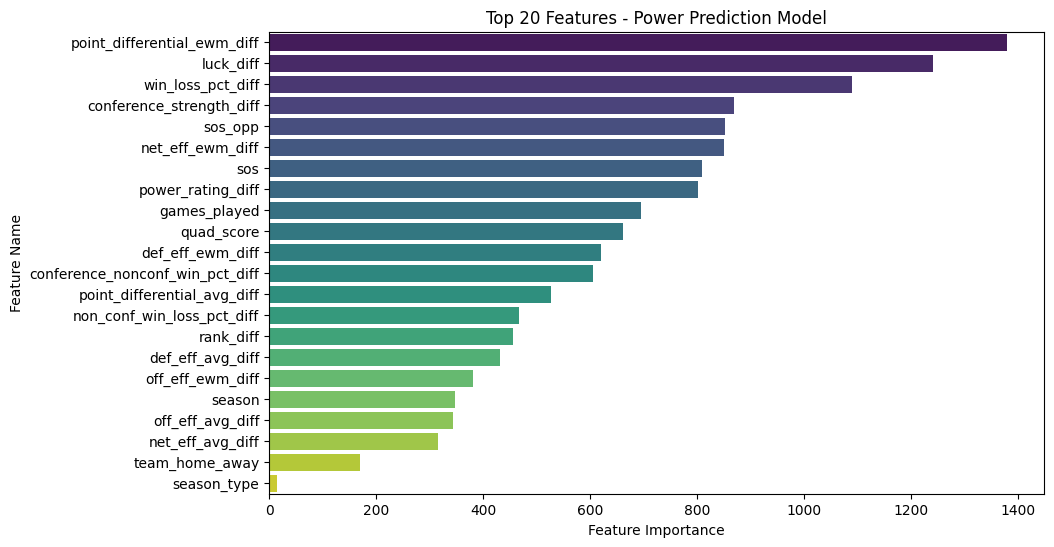

In [49]:
plot_feature_importance(model_power, X_base_train_power, "Power Prediction Model")


In [56]:
meta_feature_cols = ['stat_model_pred', 'elo_model_pred', 'power_model_pred']

meta_train = pd.DataFrame({
    'stat_model_pred': lgbm_stat_meta_train_pred,
    'elo_model_pred': lgbm_elo_meta_train_pred,
    'power_model_pred': lgbm_power_meta_train_pred,
})

meta_validation = pd.DataFrame({
    'stat_model_pred': lgbm_stat_validation_pred,
    'elo_model_pred': lgbm_elo_validation_pred,
    'power_model_pred': lgbm_power_validation_pred,
})

meta_test = pd.DataFrame({
    'stat_model_pred': lgbm_stat_pred,
    'elo_model_pred': lgbm_elo_pred,
    'power_model_pred': lgbm_power_pred,
})

from sklearn.linear_model import Ridge

meta_model_reg = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0, random_state=42)  # You can tune alpha as needed
)

meta_model_reg.fit(
    meta_train,
    y_meta_train,
    ridge__sample_weight=meta_train_sample_weights
    # Optionally add sample_weight here if available
)

winner_meta_validation_pred = meta_model_reg.predict(meta_validation)
winner_meta_pred = meta_model_reg.predict(meta_test)
meta_validation_mae = mean_absolute_error(y_validation, winner_meta_validation_pred)
meta_test_mae = mean_absolute_error(y_test, winner_meta_pred)

print(f"Meta regression model training rows: {len(meta_train)}")
print(f"Meta regression model validation MAE: {meta_validation_mae:.4f}")
print(f"Meta regression model test MAE: {meta_test_mae:.4f}")

meta_coefficients = pd.Series(
    meta_model_reg.named_steps['ridge'].coef_,
    index=meta_feature_cols,
).sort_values(ascending=False)

meta_coefficients.to_frame('coefficient')


Meta regression model training rows: 18076
Meta regression model validation MAE: 9.1957
Meta regression model test MAE: 9.3544


,coefficient
elo_model_pred,4.242129
stat_model_pred,2.744011
power_model_pred,2.495343


In [57]:
print_regression_stats(y_test, winner_meta_pred, "Meta Model Test")



===== Meta Model Test Regression Stats =====
Mean Squared Error (MSE):      143.4874
Root Mean Squared Error (RMSE):143.4874
Mean Absolute Error (MAE):     9.3544
R^2 Score:                     0.4306
